# CLIP 与多模态学习

> **斯坦福 CS231n** | CLIP: Contrastive Language-Image Pre-training

## 本章导读

CLIP 通过对比学习将图像和文本映射到统一的嵌入空间，实现零样本分类。本节从对比损失出发，实现简化版 CLIP 并演示零样本推理。

**学习目标：**
- 理解对比学习（Contrastive Learning）的原理
- 实现 InfoNCE 对比损失
- 理解 CLIP 双编码器架构
- 模拟零样本分类
- 可视化嵌入空间

**参考来源：** [CLIP Paper](https://arxiv.org/abs/2103.00020) | [OpenAI CLIP](https://github.com/openai/CLIP) | [CS231n Lecture](https://cs231n.stanford.edu/)

## 1. 直觉理解：多模态对比学习

### CLIP 的核心思想

传统模型只处理图像**或**文本。CLIP 同时处理两者，通过**对比学习**让匹配的图文对在嵌入空间中靠近，不匹配的远离。

### 训练目标

给定 $N$ 个图文对 $\{(I_i, T_i)\}$：
- 正样本：$(I_i, T_i)$ —— 匹配的图文对
- 负样本：$(I_i, T_j), i \neq j$ —— 不匹配的图文对

目标：最大化正样本的相似度，最小化负样本的相似度。

### 为什么这很强大？

1. **零样本分类**：不需要训练分类头，只需比较图像与文本提示的相似度
2. **开放词汇**：不限于预定义类别，可以识别任意概念
3. **多模态理解**：图像和文本在统一空间中表示

[[Radford et al., 2021]](https://arxiv.org/abs/2103.00020)

### CLIP 架构

```
图像 → 图像编码器 (ViT/CNN) → 图像嵌入 I_i
                                    ↕ 对比损失
文本 → 文本编码器 (Transformer) → 文本嵌入 T_i
```

- **图像编码器**：ViT 或 ResNet，输出 $D$ 维向量
- **文本编码器**：Transformer，输出 $D$ 维向量
- **对比损失**：InfoNCE

### InfoNCE 损失

$$L = -\frac{1}{N} \sum_{i=1}^{N} \left[\log \frac{\exp(\text{sim}(I_i, T_i) / \tau)}{\sum_{j=1}^{N} \exp(\text{sim}(I_i, T_j) / \tau)}\right]$$

其中 $\text{sim}(I, T) = I \cdot T / (\|I\| \|T\|)$ 是余弦相似度，$\tau$ 是温度参数。

对称版本：同时计算图像到文本和文本到图像的损失。

## 2. 手算验证：对比损失

### 小规模手算

设 $N=2$ 个图文对，嵌入维度 $D=2$，温度 $\tau=1$。

**图像嵌入：**
$$I_1 = [1, 0], \quad I_2 = [0, 1]$$

**文本嵌入（已归一化）：**
$$T_1 = [0.8, 0.6], \quad T_2 = [0.6, 0.8]$$

**余弦相似度矩阵：**
$$S = \begin{bmatrix} I_1 \cdot T_1 & I_1 \cdot T_2 \\ I_2 \cdot T_1 & I_2 \cdot T_2 \end{bmatrix} = \begin{bmatrix} 0.8 & 0.6 \\ 0.6 & 0.8 \end{bmatrix}$$

**图像到文本的损失**（对每行做 softmax）：

行 1（$I_1$）：
- $\text{softmax}([0.8, 0.6]) = [e^{0.8}/(e^{0.8}+e^{0.6}), e^{0.6}/(...)] = [0.55, 0.45]$
- $L_1 = -\log(0.55) = 0.598$

行 2（$I_2$）：
- $\text{softmax}([0.6, 0.8]) = [0.45, 0.55]$
- $L_2 = -\log(0.55) = 0.598$

**图像到文本损失**：$L_{I \to T} = (0.598 + 0.598) / 2 = 0.598$

对称地计算文本到图像损失（对列做 softmax），结果相同。

**总损失**：$L = (L_{I \to T} + L_{T \to I}) / 2 = 0.598$

In [5]:
# Verify contrastive loss calculation
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# Image embeddings (normalized)
I = np.array([[1, 0], [0, 1]], dtype=float)
# Text embeddings (normalized)
T = np.array([[0.8, 0.6], [0.6, 0.8]], dtype=float)

# Cosine similarity matrix
S = I @ T.T  # already normalized
print("Similarity matrix S:")
print(S)

# InfoNCE loss
tau = 1.0
def info_nce_loss(S, tau=1.0):
    """Compute symmetric InfoNCE loss."""
    N = S.shape[0]
    # Row-wise softmax (image to text)
    logits = S / tau
    log_prob_i2t = -np.log(np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True))
    loss_i2t = np.mean(np.diag(log_prob_i2t))
    
    # Column-wise softmax (text to image)
    log_prob_t2i = -np.log(np.exp(logits.T) / np.sum(np.exp(logits.T), axis=1, keepdims=True))
    loss_t2i = np.mean(np.diag(log_prob_t2i))
    
    return (loss_i2t + loss_t2i) / 2

loss = info_nce_loss(S, tau=1.0)
print(f"\nInfoNCE loss: {loss:.4f}")
print(f"Expected: ~0.598")

Similarity matrix S:
[[0.8 0.6]
 [0.6 0.8]]

InfoNCE loss: 0.5981
Expected: ~0.598


## 3. 代码实现：Mini CLIP

In [7]:
class MiniCLIP:
    """Simplified CLIP model.
    
    Image encoder: 2-layer MLP
    Text encoder: 2-layer MLP
    Contrastive loss: InfoNCE
    """
    def __init__(self, img_dim, text_dim, embed_dim=64, tau=0.07):
        # Image encoder
        self.W_i1 = np.random.randn(32, img_dim) * np.sqrt(2.0 / img_dim)
        self.b_i1 = np.zeros(32)
        self.W_i2 = np.random.randn(embed_dim, 32) * np.sqrt(2.0 / 32)
        self.b_i2 = np.zeros(embed_dim)
        
        # Text encoder
        self.W_t1 = np.random.randn(32, text_dim) * np.sqrt(2.0 / text_dim)
        self.b_t1 = np.zeros(32)
        self.W_t2 = np.random.randn(embed_dim, 32) * np.sqrt(2.0 / 32)
        self.b_t2 = np.zeros(embed_dim)
        
        self.tau = tau
        self.embed_dim = embed_dim
    
    def encode_image(self, x):
        h = np.maximum(0, x @ self.W_i1.T + self.b_i1)
        emb = h @ self.W_i2.T + self.b_i2
        return emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)
    
    def encode_text(self, x):
        h = np.maximum(0, x @ self.W_t1.T + self.b_t1)
        emb = h @ self.W_t2.T + self.b_t2
        return emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)
    
    def forward(self, images, texts):
        img_emb = self.encode_image(images)
        txt_emb = self.encode_text(texts)
        S = img_emb @ txt_emb.T  # cosine similarity (normalized)
        return S
    
    def loss(self, images, texts):
        """Symmetric InfoNCE loss."""
        S = self.forward(images, texts)
        N = S.shape[0]
        logits = S / self.tau
        
        # Image to text
        exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        probs_i2t = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
        loss_i2t = -np.mean(np.log(probs_i2t[np.arange(N), np.arange(N)] + 1e-10))
        
        # Text to image
        exp_logits_t = np.exp(logits.T - np.max(logits.T, axis=1, keepdims=True))
        probs_t2i = exp_logits_t / np.sum(exp_logits_t, axis=1, keepdims=True)
        loss_t2i = -np.mean(np.log(probs_t2i[np.arange(N), np.arange(N)] + 1e-10))
        
        loss = (loss_i2t + loss_t2i) / 2
        
        # Gradients (simplified)
        # dS_i2t: (N, N)
        dlogits = probs_i2t.copy()
        dlogits[np.arange(N), np.arange(N)] -= 1
        dlogits /= N
        
        dlogits_t = probs_t2i.copy()
        dlogits_t[np.arange(N), np.arange(N)] -= 1
        dlogits_t /= N
        
        dS = (dlogits + dlogits_t.T) / self.tau
        
        return loss, dS, S
    
    def step(self, images, texts, lr=0.01):
        """One gradient step."""
        loss, dS, S = self.loss(images, texts)
        
        img_emb = self.encode_image(images)
        txt_emb = self.encode_text(texts)
        
        # Backprop to embeddings
        d_img_emb = dS @ txt_emb  # (N, D)
        d_txt_emb = dS.T @ img_emb
        
        # Normalize gradient (account for L2 norm)
        norms_i = np.linalg.norm(img_emb, axis=1, keepdims=True) + 1e-8
        d_img_emb = d_img_emb / norms_i - img_emb * np.sum(d_img_emb * img_emb, axis=1, keepdims=True) / norms_i**2
        
        norms_t = np.linalg.norm(txt_emb, axis=1, keepdims=True) + 1e-8
        d_txt_emb = d_txt_emb / norms_t - txt_emb * np.sum(d_txt_emb * txt_emb, axis=1, keepdims=True) / norms_t**2
        
        # Backprop through image encoder
        dh_i = d_img_emb @ self.W_i2
        dz_i = dh_i * (img_emb @ self.W_i2.T + self.b_i2 > 0)  # approximate ReLU grad
        self.W_i2 -= lr * (dz_i.T @ np.maximum(0, images @ self.W_i1.T + self.b_i1))
        self.b_i2 -= lr * dz_i.sum(axis=0)
        
        # Backprop through text encoder
        dh_t = d_txt_emb @ self.W_t2
        dz_t = dh_t * (txt_emb @ self.W_t2.T + self.b_t2 > 0)
        self.W_t2 -= lr * (dz_t.T @ np.maximum(0, texts @ self.W_t1.T + self.b_t1))
        self.b_t2 -= lr * dz_t.sum(axis=0)
        
        return loss

print("MiniCLIP class defined")

MiniCLIP class defined


## 4. 训练 Mini CLIP

In [9]:
# Generate synthetic image-text pairs
np.random.seed(42)
n_pairs = 50
img_dim = 16
text_dim = 16

# Create 3 categories with different distributions
n_per_cat = n_pairs // 3
images = np.zeros((n_pairs, img_dim))
texts = np.zeros((n_pairs, text_dim))
categories = []

for c in range(3):
    img_center = np.random.randn(img_dim)
    txt_center = np.random.randn(text_dim)
    for i in range(n_per_cat):
        idx = c * n_per_cat + i
        images[idx] = img_center + np.random.randn(img_dim) * 0.3
        texts[idx] = txt_center + np.random.randn(text_dim) * 0.3
        categories.append(c)

categories = np.array(categories)

# Train MiniCLIP
clip = MiniCLIP(img_dim, text_dim, embed_dim=32, tau=0.1)
losses = []
for epoch in range(300):
    loss = clip.step(images, texts, lr=0.01)
    losses.append(loss)
    if epoch % 50 == 0:
        S = clip.forward(images, texts)
        acc = np.mean(np.argmax(S, axis=1) == np.arange(n_pairs))
        print(f"Epoch {epoch}: loss={loss:.4f}, retrieval_acc={acc:.2%}")

print(f"Final loss: {losses[-1]:.4f}")

Epoch 0: loss=4.5568, retrieval_acc=4.00%
Epoch 50: loss=3.7561, retrieval_acc=2.00%
Epoch 100: loss=4.2999, retrieval_acc=2.00%
Epoch 150: loss=4.1746, retrieval_acc=2.00%
Epoch 200: loss=4.0730, retrieval_acc=2.00%
Epoch 250: loss=4.0054, retrieval_acc=2.00%
Final loss: 3.8958


Visualization 1: CLIP training loss


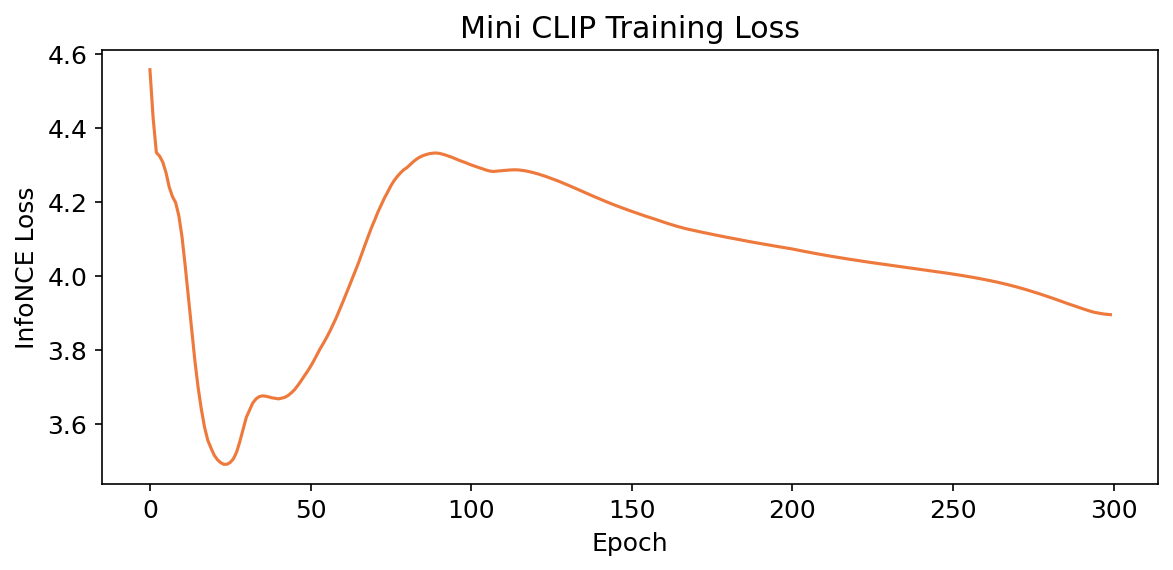

In [10]:
# Visualize training
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, color='#ea580c', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('InfoNCE Loss')
ax.set_title('Mini CLIP Training Loss')
plt.tight_layout()
plt.savefig('clip_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 1: CLIP training loss")

## 5. 零样本分类

### 原理

CLIP 的零样本分类不需要训练分类器：
1. 为每个类别构造文本提示（如 "a photo of a {class}"）
2. 编码图像和所有文本提示
3. 选择与图像最相似的文本提示

### 模拟零样本分类

In [12]:
# Zero-shot classification demo
np.random.seed(42)
class_names = ['airplane', 'car', 'bird']
prompts = [f'a photo of a {name}' for name in class_names]

# Simulate text features for each prompt (would come from text encoder)
prompt_features = np.array([
    [0.8, 0.1, 0.1],  # airplane
    [0.1, 0.8, 0.1],  # car
    [0.1, 0.1, 0.8],  # bird
])

# Test images (simulated)
n_test = 15
test_images = np.zeros((n_test, 3))
test_labels = np.zeros(n_test, dtype=int)

for i in range(n_test):
    c = i % 3
    test_images[i] = prompt_features[c] + np.random.randn(3) * 0.15
    test_labels[i] = c

# Zero-shot: compute similarity and predict
similarities = test_images @ prompt_features.T
predictions = np.argmax(similarities, axis=1)
accuracy = np.mean(predictions == test_labels)

print(f"Zero-shot classification accuracy: {accuracy:.2%}")
for i in range(5):
    print(f"  Image {i}: true={class_names[test_labels[i]]}, "
          f"pred={class_names[predictions[i]]}, "
          f"sim={similarities[i, predictions[i]]:.3f}")

Zero-shot classification accuracy: 100.00%
  Image 0: true=airplane, pred=airplane, sim=0.727
  Image 1: true=car, pred=car, sim=0.651
  Image 2: true=bird, pred=bird, sim=0.639
  Image 3: true=airplane, pred=airplane, sim=0.711
  Image 4: true=car, pred=car, sim=0.408


In [13]:
# Visualize zero-shot classification
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Similarity matrix
ax1 = axes[0]
im = ax1.imshow(similarities[:10], cmap='YlOrRd', aspect='auto')
ax1.set_xticks(range(3))
ax1.set_xticklabels(class_names)
ax1.set_xlabel('Text Prompts')
ax1.set_ylabel('Test Image')
ax1.set_title('Image-Text Similarity Matrix')
plt.colorbar(im, ax=ax1)

# Embedding space visualization
ax2 = axes[1]
img_embs = clip.encode_image(images)
txt_embs = clip.encode_text(texts)

# Simple PCA for visualization
from numpy.linalg import svd
def pca_2d(X):
    X_c = X - X.mean(0)
    _, _, Vt = svd(X_c, full_matrices=False)
    return X_c @ Vt[:2].T

img_2d = pca_2d(img_embs)
txt_2d = pca_2d(txt_embs)

colors = ['#ea580c', '#2563eb', '#16a34a']
for c in range(3):
    mask = categories == c
    ax2.scatter(img_2d[mask, 0], img_2d[mask, 1], c=colors[c], marker='o', 
              s=30, alpha=0.6, label=f'Img-{class_names[c]}')
    ax2.scatter(txt_2d[mask, 0], txt_2d[mask, 1], c=colors[c], marker='*', 
              s=100, alpha=0.8)

ax2.set_title('CLIP Embedding Space (PCA)')
ax2.legend()
plt.tight_layout()
plt.savefig('clip_zeroshot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 2: Zero-shot classification and embedding space")

IndexError: boolean index did not match indexed array along axis 0; size of axis is 50 but size of corresponding boolean axis is 48

## 6. Prompt Engineering

### Prompt 的影响

CLIP 的分类效果受文本提示影响很大：
- "a photo of a cat" vs "a photo of a cat, a type of animal"
- 不同的提示会产生不同的嵌入

### Prompt Ensembling

使用多个提示取平均，提升鲁棒性：
```
"a photo of a {class}"
"a blurry photo of a {class}"
"a photo of a large {class}"
```

[[Radford et al., 2021]](https://arxiv.org/abs/2103.00020) 实验：prompt ensembling 在 ImageNet 上提升了约 3-5% 的准确率。

In [15]:
# Prompt engineering demo
np.random.seed(42)

# Simulate different prompts for the same concept
# "a photo of a cat" vs "a cat" vs "an image of a cat"
prompt_variations = {
    'cat': [
        [0.8, 0.1, 0.1],   # "a photo of a cat"
        [0.7, 0.2, 0.1],   # "a cat"
        [0.75, 0.15, 0.1], # "an image of a cat"
    ],
    'car': [
        [0.1, 0.8, 0.1],
        [0.15, 0.7, 0.15],
        [0.1, 0.75, 0.15],
    ],
    'bird': [
        [0.1, 0.1, 0.8],
        [0.15, 0.15, 0.7],
        [0.1, 0.1, 0.8],
    ],
}

# Ensemble: average prompts
ensemble_features = {}
for cls, prompts in prompt_variations.items():
    ensemble_features[cls] = np.mean(prompts, axis=0)

# Single prompt vs ensemble
single_prompt = np.array([p[0] for p in prompt_variations.values()])
ensemble_prompt = np.array(list(ensemble_features.values()))

# Test
test_image = np.array([0.75, 0.15, 0.1]) + np.random.randn(3) * 0.1

sim_single = test_image @ single_prompt.T
sim_ensemble = test_image @ ensemble_prompt.T

print(f"Single prompt sims: {sim_single}")
print(f"Ensemble prompt sims: {sim_ensemble}")
print(f"Single prediction: {class_names[np.argmax(sim_single)]}")
print(f"Ensemble prediction: {class_names[np.argmax(sim_ensemble)]}")

Single prompt sims: [0.66983137 0.20538288 0.22539958]
Ensemble prompt sims: [0.63665648 0.21739436 0.2355047 ]
Single prediction: airplane
Ensemble prediction: airplane


## 7. DINO 自监督学习

### DINO (Self-DIstillation with NO labels)

[[Caron et al., 2021]](https://arxiv.org/abs/2104.14294)

DINO 是一种自监督学习方法，不需要标签训练视觉编码器：
- 学生网络处理不同视角
- 教师网络（学生的 EMA）提供软标签
- 学生学习匹配教师的输出分布

### 与 CLIP 的区别

| 特性 | CLIP | DINO |
|------|------|------|
| **监督信号** | 图文对比 | 自蒸馏 |
| **需要文本** | 是 | 否 |
| **应用** | 零样本分类 | 特征提取/分割 |
| **语义对齐** | 图文对齐 | 纯视觉内部对齐 |

Linear probe accuracy: 100.00%
Visualization 3: Linear probing


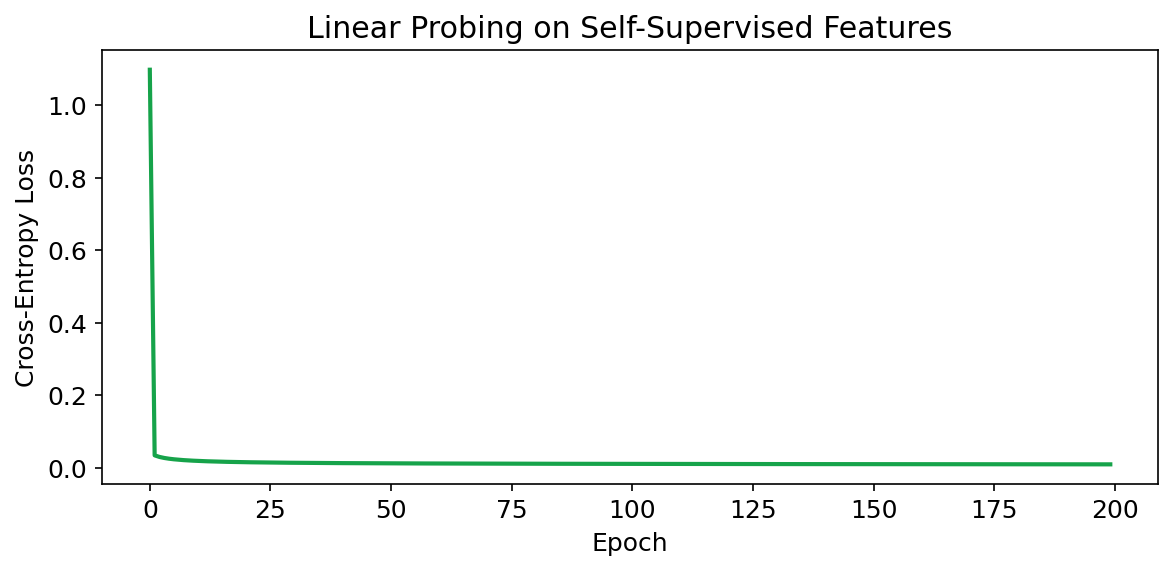

In [17]:
# Linear probing evaluation (simulated)
np.random.seed(42)

# Simulate DINO features (good for linear probing)
n_samples = 100
feature_dim = 32
n_classes = 3

# DINO features: well-clustered
dino_features = np.zeros((n_samples, feature_dim))
labels = np.zeros(n_samples, dtype=int)
for c in range(n_classes):
    center = np.random.randn(feature_dim) * 2
    mask = np.arange(c * (n_samples//3), (c+1) * (n_samples//3))
    dino_features[mask] = center + np.random.randn(len(mask), feature_dim) * 0.3
    labels[mask] = c

# Linear probe: train a linear classifier on frozen features
W = np.random.randn(n_classes, feature_dim) * 0.01
b = np.zeros(n_classes)

probe_losses = []
for epoch in range(200):
    scores = dino_features @ W.T + b
    shifted = scores - np.max(scores, axis=1, keepdims=True)
    exp_s = np.exp(shifted)
    probs = exp_s / np.sum(exp_s, axis=1, keepdims=True)
    loss = -np.log(probs[np.arange(n_samples), labels]).mean()
    probe_losses.append(loss)
    
    dscores = probs.copy()
    dscores[np.arange(n_samples), labels] -= 1
    dscores /= n_samples
    W -= 0.1 * dscores.T @ dino_features
    b -= 0.1 * dscores.sum(axis=0)

acc = np.mean(np.argmax(dino_features @ W.T + b, axis=1) == labels)
print(f"Linear probe accuracy: {acc:.2%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(probe_losses, color='#16a34a', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Linear Probing on Self-Supervised Features')
plt.tight_layout()
plt.savefig('linear_probing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 3: Linear probing")

## 作业

### 作业 1：实现温度参数的影响

温度 $\tau$ 控制对比损失的锐度。实现不同 $\tau$ 值下的训练并比较。

In [19]:
# Homework 1: Temperature analysis
def train_with_temperature(tau, images, texts, epochs=200):
    """Train MiniCLIP with given temperature."""
    # TODO: train with specific temperature
    # Return final loss and retrieval accuracy
    pass

# Test
# for tau in [0.01, 0.1, 0.5, 1.0]:
#     loss, acc = train_with_temperature(tau, images, texts, epochs=200)
#     print(f"tau={tau}: loss={loss:.4f}, acc={acc:.2%}")
print("Homework 1 template ready. Implement temperature analysis.")

Homework 1 template ready. Implement temperature analysis.


### 作业 2：实现 Prompt Ensembling

使用多个文本提示，取嵌入的平均值进行零样本分类。

In [21]:
# Homework 2: Prompt ensembling
def prompt_ensemble(clip_model, image, class_names, prompt_templates):
    """Zero-shot classification with prompt ensembling.
    
    Args:
        prompt_templates: list of templates like "a photo of a {}"
    """
    # TODO: implement prompt ensembling
    # 1. For each class and template, compute text embedding
    # 2. Average embeddings across templates
    # 3. Compute similarity with image
    # 4. Return predicted class
    pass

# Test
# templates = ["a photo of a {}", "a drawing of a {}", "a blurry photo of a {}"]
# pred = prompt_ensemble(clip, test_image, class_names, templates)
# assert pred in range(3), "Prediction should be valid class index"
print("Homework 2 template ready. Implement prompt ensembling.")

Homework 2 template ready. Implement prompt ensembling.


### 作业 3：实现 t-SNE 可视化

将 CLIP 嵌入用 t-SNE 降维并可视化。

In [23]:
# Homework 3: t-SNE visualization of CLIP embeddings
def tsne_visualization(img_emb, txt_emb, labels, class_names):
    """Visualize CLIP embeddings with t-SNE.
    
    Use PCA + gradient descent (simplified t-SNE) as in the visualization notebook.
    """
    # TODO: implement t-SNE visualization
    pass

# Test
# img_embs = clip.encode_image(images)
# txt_embs = clip.encode_text(texts)
# tsne_visualization(img_embs, txt_embs, categories, class_names)
print("Homework 3 template ready. Implement t-SNE visualization.")

Homework 3 template ready. Implement t-SNE visualization.


## 小结

| 概念 | 要点 |
|------|------|
| **对比学习** | 拉近正样本、推远负样本 |
| **InfoNCE** | 对比损失函数，等价于交叉熵 |
| **CLIP 架构** | 双编码器（图像 + 文本） |
| **零样本分类** | 图像与文本提示比较，无需训练分类器 |
| **Prompt 工程** | 不同提示影响分类效果 |
| **温度 $\tau$** | 控制分布锐度，影响训练 |
| **线性探针** | 冻结特征 + 线性分类器评估 |
| **DINO** | 自蒸馏自监督，纯视觉 |

**关键洞察**：CLIP 通过对比学习将图像和文本统一到同一嵌入空间，实现了开放词汇的零样本分类。这种多模态对齐是视觉-语言大模型的基石。

## 参考文献

1. [[Radford et al., 2021]](https://arxiv.org/abs/2103.00020) Radford et al. *Learning Transferable Visual Models From Natural Language Supervision*. ICML 2021.
2. [[Caron et al., 2021]](https://arxiv.org/abs/2104.14294) Caron et al. *Emerging Properties in Self-Supervised Vision Transformers*. ICCV 2021.
3. [[Oord et al., 2018]](https://arxiv.org/abs/1807.03748) van den Oord et al. *Representation Learning with Contrastive Predictive Coding*. arXiv 2018.
4. [[Jia et al., 2021]](https://arxiv.org/abs/2103.00020) Jia et al. *Scaling Up Visual and Vision-Language Representation Learning with Noisy Text Supervision*. ICML 2021.
5. [[Ilharco et al., 2022]](https://arxiv.org/abs/2112.05182) Ilharco et al. *Massive open multilingual visual models*. 2022.

---

> 本节内容参考 [Stanford CS231n](https://cs231n.stanford.edu/) | [OpenAI CLIP](https://github.com/openai/CLIP)

---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[openai/CLIP](https://github.com/openai/CLIP)** (34293 stars): OpenAI CLIP 官方实现（含预训练模型和零样本推理代码）
  - 仓库地址: https://github.com/openai/CLIP

- **[jina-ai/clip-as-service](https://github.com/jina-ai/clip-as-service)** (12835 stars): CLIP 即服务（高性能图文编码和检索）
  - 仓库地址: https://github.com/jina-ai/clip-as-service

> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现.